
# Imaging Demo

How to create visibility from pixel data and make images.

The example uses ``stixpy`` to obtain STIX pixel data and convert these into visibilities and ``xrayvisim``
to make the images.

Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('stixpy').setLevel(logging.WARNING)
logger = logging.getLogger('stixpy')
logger.setLevel(logging.WARNING)
# Remove existing handlers (optional but effective)
logger.handlers.clear()
# Add a simple handler if you still want warnings/errors printed
handler = logging.StreamHandler()
handler.setLevel(logging.WARNING)
logger.addHandler(handler)
logging.getLogger('stixpy').disabled = True

import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from astropy.coordinates import SkyCoord
from sunpy.coordinates import HeliographicStonyhurst, Helioprojective
from sunpy.map import Map, make_fitswcs_header
from sunpy.time import TimeRange
from xrayvision.clean import vis_clean
from xrayvision.imaging import vis_to_image, vis_to_map
from xrayvision.mem import mem, resistant_mean

import stixpy                          # ← This registers the a.stix attrs
from stixpy.calibration.visibility import calibrate_visibility, create_meta_pixels, create_visibility
from stixpy.coordinates.frames import STIXImaging
from stixpy.coordinates.transforms import get_hpc_info
from stixpy.imaging.em import em
from stixpy.map.stix import STIXMap  # noqa
from stixpy.product import Product

# logger = logging.getLogger(__name__)

In [2]:
import sunpy
sunpy.__version__

'6.1.2'

In [3]:
import stixpy
stixpy.__version__

'0.2.1'

Read science file as Product



In [4]:
import requests
import urllib.request
from bs4 import BeautifulSoup

def find_links(url='http://www.python.org'):
    """
    Get all the links in a webpage.
    Source: https://stackoverflow.com/questions/20150184/make-a-list-of-all-the-files-on-a-website
    """
    soup = BeautifulSoup(requests.get(url).text)
    hrefs = []
    for a in soup.find_all('a'):
        hrefs.append(a['href'])
    return hrefs

In [5]:
start_date       = '2026-01-18'
YEAR, MONTH, DAY = start_date.split('-')
print(YEAR, MONTH, DAY)

# show the links of the CPD SCI files
sci_url = f'https://pub099.cs.technik.fhnw.ch/fits/L1/{YEAR}/{MONTH}/{DAY}/SCI/'
list_sci_links = find_links(url=sci_url)

# show what you've found
for i, link in enumerate(list_sci_links):
    print(i, link)

2026 01 18
0 ?C=N;O=D
1 ?C=M;O=A
2 ?C=S;O=A
3 ?C=D;O=A
4 /fits/L1/2026/01/18/
5 solo_L1_stix-sci-xray-cpd_20260118T000340-20260118T000644_V02_2601189940-56457.fits
6 solo_L1_stix-sci-xray-cpd_20260118T015211-20260118T015758_V02_2601183281-56458.fits
7 solo_L1_stix-sci-xray-cpd_20260118T024118-20260118T024626_V02_2601187390-61418.fits
8 solo_L1_stix-sci-xray-cpd_20260118T030639-20260118T031036_V02_2601184405-61468.fits
9 solo_L1_stix-sci-xray-cpd_20260118T033146-20260118T045611_V02_2601187961-60116.fits
10 solo_L1_stix-sci-xray-cpd_20260118T050431-20260118T051111_V02_2601189317-61419.fits
11 solo_L1_stix-sci-xray-cpd_20260118T053610-20260118T054549_V02_2601188545-61420.fits
12 solo_L1_stix-sci-xray-cpd_20260118T055709-20260118T072243_V02_2601186017-59903.fits
13 solo_L1_stix-sci-xray-cpd_20260118T081244-20260118T082447_V02_2601183690-60117.fits
14 solo_L1_stix-sci-xray-cpd_20260118T084628-20260118T085048_V02_2601185574-61421.fits
15 solo_L1_stix-sci-xray-cpd_20260118T091308-20260118T091

In [6]:
from datetime import datetime

def extract_timerange(filename):
    # isolate the time part
    time_part = filename.split('_')[3]  # '20260118T000340-20260118T000644'
    
    start_str, end_str = time_part.split('-')
    
    t_start = datetime.strptime(start_str, '%Y%m%dT%H%M%S')
    t_end   = datetime.strptime(end_str,   '%Y%m%dT%H%M%S')
    
    return t_start, t_end


def is_overlap(file_start, file_end, query_start, query_end):
    # overlap condition
    return not (file_end < query_start or file_start > query_end)

In [7]:
sci_query_start = datetime(2026, 1, 18, 17, 40, 0)
sci_query_end   = datetime(2026, 1, 18, 17, 50, 0)

valid_sci_files = []

for link in list_sci_links:
    if not link.endswith('.fits'):
        continue
    
    f_start, f_end = extract_timerange(link)

    if 'cpd' in link:    
        if is_overlap(f_start, f_end, sci_query_start, sci_query_end):
            valid_sci_files.append(link)

print(valid_sci_files)
cpd_sci =  Product(f'{sci_url}/{valid_sci_files[0]}')

['solo_L1_stix-sci-xray-cpd_20260118T164424-20260118T181559_V02_2601189567-59714.fits']


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L1_stix-sci-xray-cpd_20260118T164424-20260118T181559_V02_2601189567-59714.fits:   0%|          | 0.00/215…

In [8]:
cpd_sci

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7e72df722090>
    Start: 2026-01-18 16:44:24
    End:   2026-01-18 18:15:59
    Center:2026-01-18 17:30:11
    Duration:0.06359606481481461 days or
           1.5263055555555507 hours or
           91.57833333333303 minutes or
           5494.6999999999825 seconds
    DetectorMasks
    [0...2251]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...2251]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

Read background file as Product



In [9]:
bkg_query_start = datetime(2026, 1, 18, 17, 30, 0)
bkg_query_end   = datetime(2026, 1, 18, 17, 39, 59)

valid_bkg_files = []

for link in list_sci_links:
    if not link.endswith('.fits'):
        continue
    
    f_start, f_end = extract_timerange(link)

    if 'cpd' in link:    
        if is_overlap(f_start, f_end, bkg_query_start, bkg_query_end):
            valid_bkg_files.append(link)

print(valid_bkg_files)
cpd_bkg =  Product(f'{sci_url}/{valid_bkg_files[0]}')

['solo_L1_stix-sci-xray-cpd_20260118T164424-20260118T181559_V02_2601189567-59714.fits']


In [10]:
cpd_bkg

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7e72592c9010>
    Start: 2026-01-18 16:44:24
    End:   2026-01-18 18:15:59
    Center:2026-01-18 17:30:11
    Duration:0.06359606481481461 days or
           1.5263055555555507 hours or
           91.57833333333303 minutes or
           5494.6999999999825 seconds
    DetectorMasks
    [0...2251]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...2251]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

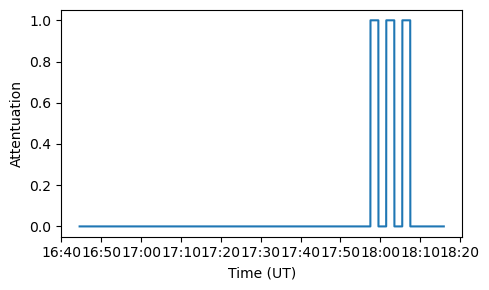

In [11]:
fig = plt.figure(figsize=[5,3])
ax  = fig.add_subplot(111)
ax.plot(cpd_sci.times.datetime, cpd_sci.data['rcr'])
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Attentuation')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

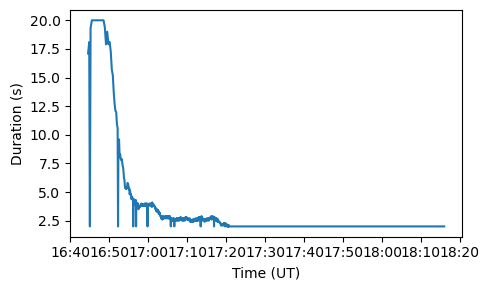

In [12]:
fig = plt.figure(figsize=[5,3])
ax  = fig.add_subplot(111)
ax.plot(cpd_sci.times.datetime, cpd_sci.duration.to_value('s'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Duration (s)')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

Set time and energy ranges which will be considered for the science and the background file



In [13]:
time_range_sci = [sci_query_start, sci_query_end]
time_range_bkg = [bkg_query_start, bkg_query_end] # Set this range larger than the actual observation time
energy_range = [25, 28]*u.keV

Create the meta pixel, A, B, C, D for the science and the background data



In [14]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

meta_pixels_bkg = create_meta_pixels(
    cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
)

Perform background subtraction



In [15]:
meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    ),
}

Create visibilities from the meta pixels



In [16]:
vis = create_visibility(meta_pixels_bkg_subtracted)

Obtain the necessary ephemeris data create HPC 0,0 coordinate



In [17]:
from sunpy.net import Fido, attrs as a

res = Fido.search(
    a.Time('2026-01-18T16:00', '2026-01-18T18:00'),
    a.Instrument.stix,
    a.stix.DataType.asp,
    a.stix.DataProduct.asp_ephemeris,
)

print(res)

Results from 1 Provider:

1 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2026-01-18 00:00:00.000 2026-01-18 23:59:59.999       STIX   ANC      ASP asp-ephemeris V02          -




In [18]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
center_hpc = SkyCoord(0 * u.deg, 0 * u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-17T20:56:40Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:40 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec


In [19]:
vis

Visibilities< 30, [ 0.25404573-0.19491897j -0.3429016 +0.33087682j  0.86972965+2.22645432j
  0.25069397-0.34102969j  0.25938981+0.36846931j  0.57455409+0.00960915j
  0.39386942+0.45272962j  0.95353246-0.33337996j  0.1632993 +0.13218504j
 -0.13716622-0.13744843j  0.09844775+0.15992027j -1.28585424+0.39822917j
  1.05685704-0.36078434j  1.62006936-1.19243588j  0.02295551+0.16410437j
  0.04787922-0.04413742j  0.18571172-0.04146088j -1.30396681+1.24408466j
  1.02386091+1.02066117j -1.47667176-1.96056206j  0.64497601-0.42542772j
  0.39273692-0.02566618j -0.22050751+0.32135659j  0.80491397+1.07449527j
 -0.530143  -0.65121581j  0.13013479+0.44276565j -0.10199734+0.04787575j
  0.72846549+0.17403594j  0.19007647-0.79545174j -1.48687202+0.96254865j] ct / (keV s cm2)>

In [20]:
vis.meta["time_range"]

<Time object: scale='utc' format='isot' value=['2026-01-18T17:39:59.125' '2026-01-18T17:50:01.125']>

Calibrate the visibilities

If not given will default to sun center flare location



In [21]:
cal_vis = calibrate_visibility(vis, flare_location=center_hpc)

2026-04-17T20:56:40Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:40 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-17T20:56:40Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.31418964 87.1370531 ]] arcsec
2026-04-17 20:56:40 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.31418964 87.1370531 ]] arcsec


Selected detectors 10 to 7



In [22]:
# order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_7)).ravel()

Slice the visibilities to detectors 10 - 7



In [23]:
vis10_7 = cal_vis[idx]

Set up image parameters



In [24]:
imsize = [512, 512] * u.pixel  # number of pixels of the map to reconstruct
pixel = [10, 10] * u.arcsec / u.pixel  # pixel size in arcsec

Make a full disk back projection (inverse transform) map



In [25]:
bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)

Obtain the necessary ephemeris data



In [26]:
vis_tr = TimeRange(vis.meta["time_range"])
roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
header = make_fitswcs_header(
    bp_image, coord_stix, telescope="STIX", observatory="Solar Orbiter", scale=[10, 10] * u.arcsec / u.pix
)
fd_bp_map = Map((bp_image, header))

2026-04-17T20:56:41Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:41 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17T20:56:42Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:42 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec


Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up"
Center of STIX pointing in HPC



In [27]:
header_hp = make_fitswcs_header(
    bp_image, center_hpc, scale=[10, 10] * u.arcsec / u.pix, rotation_angle=90 * u.deg + roll
)
hp_map = Map((bp_image, header_hp))
hp_map_rotated = hp_map.rotate()

Plot the both maps



Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

2026-04-17T20:56:42Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:42 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17T20:56:42Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:42 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17T20:56:42Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:42 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17T20:56:42Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:42 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17T20:56:42Z INFO stixpy.coordinates.transforms 141: Using SAS point

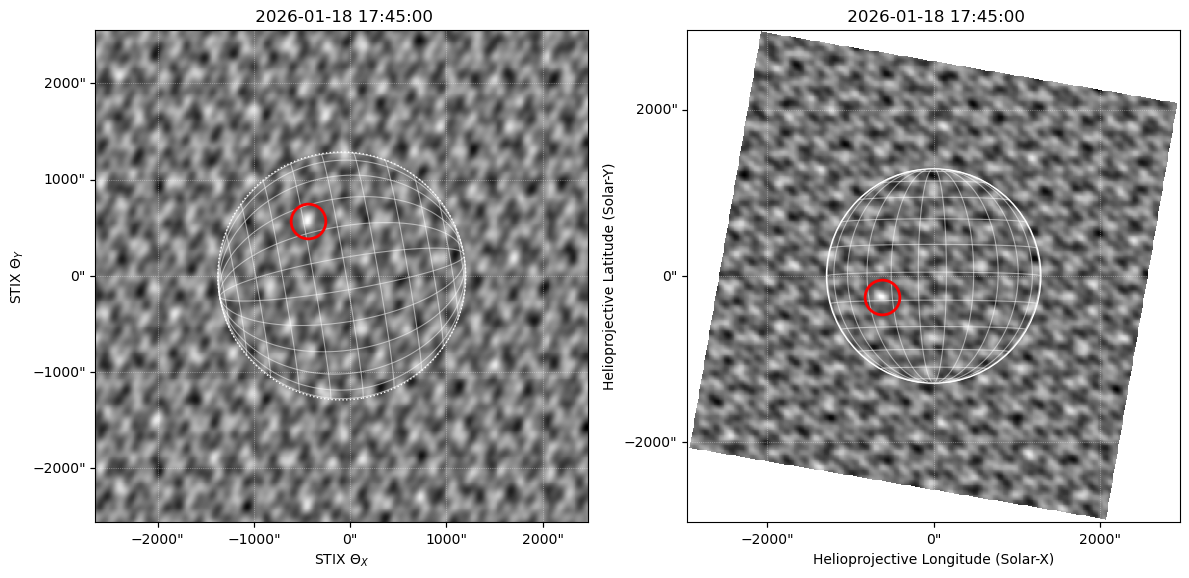

In [28]:
fig = plt.figure(layout="constrained", figsize=(12, 6))
ax = fig.subplot_mosaic(
    [["stix", "hpc"]], per_subplot_kw={"stix": {"projection": fd_bp_map}, "hpc": {"projection": hp_map_rotated}}
)
fd_bp_map.plot(axes=ax["stix"])
fd_bp_map.draw_limb()
fd_bp_map.draw_grid()

hp_map_rotated.plot(axes=ax["hpc"])
hp_map_rotated.draw_limb()
hp_map_rotated.draw_grid()

"""
Estimate the flare location and plot on top of back projection map.
Note the coordinates are automatically converted from the STIXImaging to Helioprojective.
"""
max_pixel = np.argwhere(fd_bp_map.data == fd_bp_map.data.max()).ravel() * u.pixel
# because WCS axes and array are reversed
max_stix = fd_bp_map.pixel_to_world(max_pixel[1], max_pixel[0])

ax["stix"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
ax["hpc"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
fig.tight_layout()
plt.show()

Use estimated flare location to create more accurate visibilities



In [29]:
meta_pixels_sci = create_meta_pixels(
    cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
)

meta_pixels_bkg_subtracted = {
    **meta_pixels_sci,
    "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
    "abcd_rate_error_kev_cm": np.sqrt(
        meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
    ),
}

vis = create_visibility(meta_pixels_bkg_subtracted)
cal_vis = calibrate_visibility(vis, flare_location=max_stix)

2026-04-17T20:56:53Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:53 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec


Selected detectors 10 to 3
order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....



In [30]:
isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_3)).ravel()

Create an ``xrayvsion`` visibility object



In [31]:
cal_vis.meta["offset"] = max_stix
vis10_3 = cal_vis[idx]

Set up image parameters



In [32]:
imsize = [129, 129] * u.pixel        # number of pixels of the map to reconstruct
pixel = [2, 2] * u.arcsec / u.pixel  # pixel size in arcsec

Create a back projection image with natural weighting



In [33]:
# bp_nat = vis_to_image(vis10_3, imsize, pixel_size=pixel)

Create a back projection image with uniform weighting



In [34]:
# bp_uni = vis_to_image(vis10_3, imsize, pixel_size=pixel, scheme="uniform")

Create a `sunpy.map.Map` with back projection



In [35]:
# bp_map = vis_to_map(vis10_3, imsize, pixel_size=pixel)

Crete a clean image using the clean algorithm `vis_clean`



In [36]:
niter = 200  # number of iterations
gain = 0.1   # gain used in each clean iteration
beam_width = 20.0 * u.arcsec
clean_map, model_map, resid_map = vis_clean(
    vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
)

2026-04-17T20:56:54Z INFO xrayvision.clean 124: Iter: 0, strength: 2.07758167464769, location: (np.int64(85), np.int64(68))
2026-04-17 20:56:54 - xrayvision.clean - INFO: Iter: 0, strength: 2.07758167464769, location: (np.int64(85), np.int64(68))
2026-04-17T20:56:54Z INFO xrayvision.clean 124: Iter: 25, strength: 0.7592740863641398, location: (np.int64(43), np.int64(70))
2026-04-17 20:56:54 - xrayvision.clean - INFO: Iter: 25, strength: 0.7592740863641398, location: (np.int64(43), np.int64(70))
2026-04-17T20:56:54Z INFO xrayvision.clean 124: Iter: 50, strength: 0.39525199005390266, location: (np.int64(73), np.int64(39))
2026-04-17 20:56:54 - xrayvision.clean - INFO: Iter: 50, strength: 0.39525199005390266, location: (np.int64(73), np.int64(39))
2026-04-17T20:56:54Z INFO xrayvision.clean 124: Iter: 75, strength: 0.24409838088126834, location: (np.int64(59), np.int64(72))
2026-04-17 20:56:54 - xrayvision.clean - INFO: Iter: 75, strength: 0.24409838088126834, location: (np.int64(59), np.i

Create a sunpy map for the clean image in Helioprojective



In [37]:
header = make_fitswcs_header(
    clean_map.data,
    max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
    telescope="STIX",
    observatory="Solar Orbiter",
    scale=pixel,
    rotation_angle=90 * u.deg + roll,
)

2026-04-17T20:56:57Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec
2026-04-17 20:56:57 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-0.30783844 87.05967712]] arcsec


Create a map using the MEM GE algorithm `mem`



In [38]:
# snr_value, _ = resistant_mean((np.abs(vis10_3.visibilities) / vis10_3.amplitude_uncertainty).flatten(), 3)
# percent_lambda = 2 / (snr_value**2 + 90)
# mem_map = mem(vis10_3, shape=imsize, pixel_size=pixel, percent_lambda=percent_lambda)

Create a map using the EM algorithm `EM`



In [39]:
# em_map = em(
#     meta_pixels_bkg_subtracted["abcd_rate_kev_cm"],
#     cal_vis,
#     shape=imsize,
#     pixel_size=pixel,
#     flare_location=max_stix,
#     idx=idx,
# )

# bp_map = Map((bp_nat, header)).rotate()
# mem_map = Map((mem_map.data, header)).rotate()
# em_map = Map((em_map, header)).rotate()

# , mem_map.data.max(), em_map.data.max()])

In [40]:
clean_map = Map((clean_map.data, header)).rotate()
vmax = clean_map.data.max()

Finally compare the images from each algorithm



In [41]:
# fig = plt.figure(figsize=(12, 12))
# ax = fig.subplot_mosaic(
#     [
#         ["bp", "clean"],
#         ["mem", "em"],
#     ],
#     subplot_kw={"projection": clean_map},
# )
# a = bp_map.plot(axes=ax["bp"])
# ax["bp"].set_title("Back Projection")
# b = clean_map.plot(axes=ax["clean"])
# ax["clean"].set_title("Clean")
# c = mem_map.plot(axes=ax["mem"])
# ax["mem"].set_title("MEM GE")
# d = em_map.plot(axes=ax["em"])
# ax["em"].set_title("EM")
# fig.colorbar(a, ax=ax.values())
# plt.show()

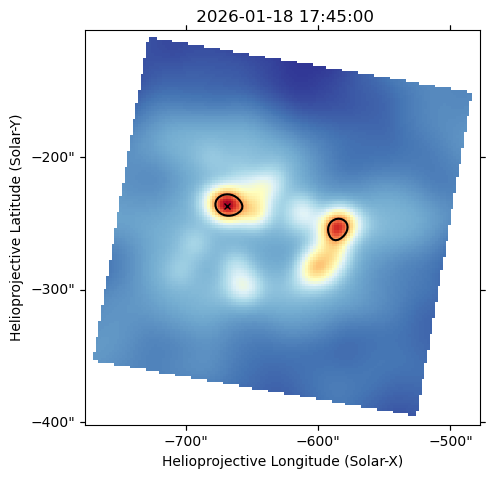

In [42]:
# Plot the Clean method
fig = plt.figure(figsize=[5,5])
ax  = fig.add_subplot(111, projection=clean_map)
clean_map.plot(axes=ax, cmap='RdYlBu_r')

with sunpy.coordinates.frames.Helioprojective.assume_spherical_screen(clean_map.observer_coordinate):
    # c0 = clean_map.draw_contours(levels=(70)*u.percent, autoalign=True, fill=True, colors='black', alpha=0.3)
    c0 = clean_map.draw_contours(levels=(70)*u.percent, axes=ax, autoalign=True, colors='black')

# find the maxima pixel locations for the clean stix map
clean_map_maxloc = np.unravel_index(np.nanargmax(clean_map.data), clean_map.data.shape)*u.pixel
# convert to sky coordinates
maxcoords = clean_map.pixel_to_world(clean_map_maxloc[1], clean_map_maxloc[0])
# plot the maxima centroids
ax.plot_coord(maxcoords, 'wx', fillstyle='none', markersize=5, linewidth=5, color='black')

ax.grid(False)
fig.tight_layout()
plt.show()

In [43]:
from datetime import datetime, timedelta

t = clean_map.meta['date-obs']

dt = datetime.fromisoformat(t)
dt_new = dt + timedelta(seconds=12)

print(t, dt_new.isoformat())

2026-01-18T17:45:00.125 2026-01-18T17:45:12.125000


In [44]:
from sunpy.net import Fido, attrs as a

aia_result = Fido.search(a.Time(t, dt_new),
                         a.Instrument('AIA'),
                         a.Wavelength(193*u.angstrom),
                         a.Sample(12*u.second)
                        )
aia_files = Fido.fetch(aia_result, site='NSO')

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [45]:
aia_files

['/net/maedoc.ap.dias.ie/maedoc/home_cr/mnedal/sunpy/data/aia.lev1.193A_2026_01_18T17_45_04.84Z.image_lev1.fits']

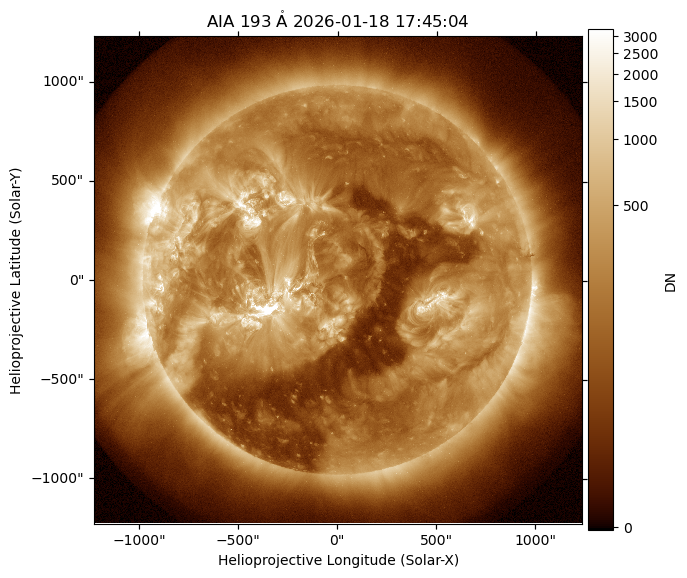

In [46]:
from astropy.visualization import ImageNormalize, SqrtStretch, LogStretch

aia = sunpy.map.Map(aia_files[0])
# aia.plot_settings['norm'] = ImageNormalize(vmin=50, vmax=3e3, stretch=SqrtStretch())
# aia.plot_settings['norm'] = ImageNormalize(vmin=-1e2, vmax=1e4, stretch=LogStretch())

fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(projection=aia)
m = aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)
fig.colorbar(m, ax=ax, pad=0.01, shrink=0.8, label=aia.meta['pixlunit'])
ax.grid(False)
fig.tight_layout()
plt.show()

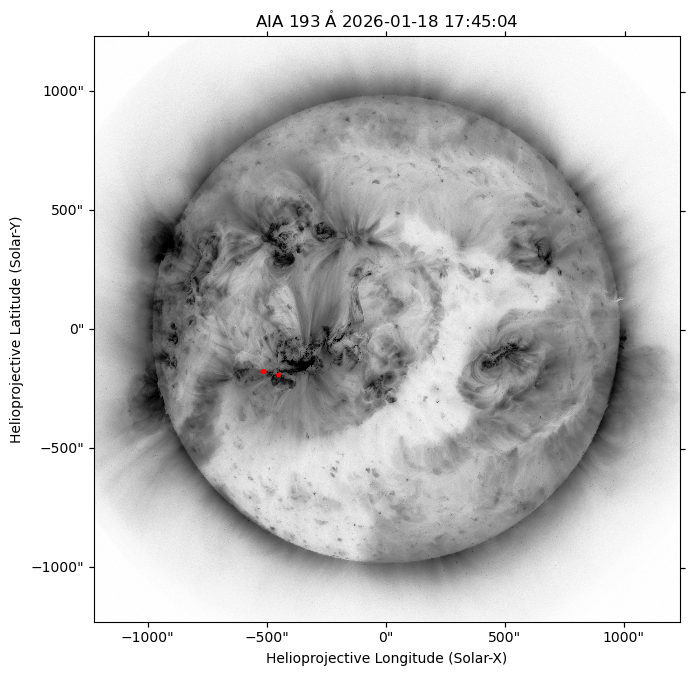

In [47]:
from sunpy.coordinates import frames

fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(111, projection=aia)
aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent, cmap='Greys')

with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
    clean_map_proj = clean_map.reproject_to(aia.wcs)

clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')

ax.grid(False)
fig.tight_layout()
plt.show()

In [48]:
# fig = plt.figure(figsize=[7,7])
# ax = fig.add_subplot(111, projection=aia)
# aia.plot(axes=ax, cmap='Greys')

# with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
#     clean_map_proj = clean_map.reproject_to(aia.wcs)
#     clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')

# ax.grid(False)
# fig.tight_layout()
# plt.show()

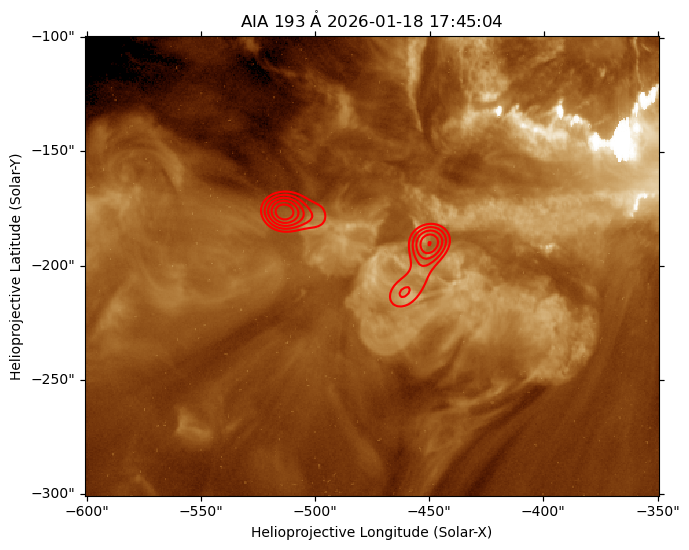

In [49]:
top_right   = SkyCoord(-350*u.arcsec, -100*u.arcsec, frame=aia.coordinate_frame)
bottom_left = SkyCoord(-600*u.arcsec, -300*u.arcsec, frame=aia.coordinate_frame)
aia_sub = aia.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(projection=aia_sub)
aia_sub.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)

with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
    clean_map_proj = clean_map.reproject_to(aia_sub.wcs)

# clean_map_proj.draw_contours(levels=np.arange(70, 100, 10)*u.percent, axes=ax, autoalign=True, colors='red')/
clean_map_proj.draw_contours(levels=[50,60,70,80,90]*u.percent, axes=ax, autoalign=True, colors='red')

ax.grid(False)
fig.tight_layout()
plt.show()

In [50]:
np.arange(70, 100, 10)

array([70, 80, 90])

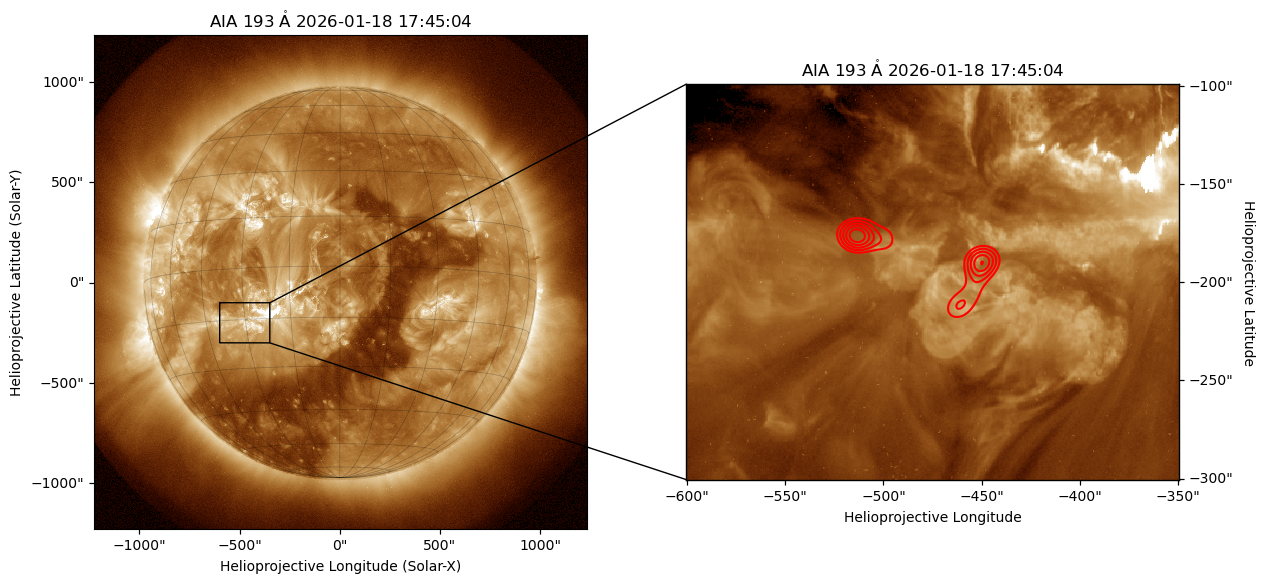

In [51]:
from matplotlib.patches import ConnectionPatch

#### The first stage is plotting the full-disk AIA 193 Ao
fig = plt.figure(figsize=[14,7])

ax1 = fig.add_subplot(121, projection=aia)
# aia.plot(axes=ax1, cmap='Greys')
aia.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
aia.draw_grid(axes=ax1, color='black', alpha=0.25, lw=0.5)
ax1.grid(b=False)

# draw the rectangle around the region we plan to showcase in the cutout image
aia.draw_quadrangle(bottom_left, top_right=top_right, edgecolor='black', lw=1)

#### The second stage is plotting the zoomed-in map
ax2 = fig.add_subplot(122, projection=aia_sub)
aia_sub.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.grid(False)

with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
    clean_map_proj = clean_map.reproject_to(aia_sub.wcs)
clean_map_proj.draw_contours(levels=[50,60,70,80,90]*u.percent, axes=ax2, autoalign=True, colors='red')

# clean up the axis labels and ticks
lon, lat = ax2.coords[0], ax2.coords[1]
lon.frame.set_linewidth(1)
lat.frame.set_linewidth(1)
lon.set_axislabel('Helioprojective Longitude',)
lon.set_ticks_position('b')
lat.set_axislabel('Helioprojective Latitude',)
lat.set_axislabel_position('r')
lat.set_ticks_position('r')
lat.set_ticklabel_position('r')

# we add two lines that will connect the two images as well as a colorbar
xpix, ypix = aia.world_to_pixel(top_right)
con1 = ConnectionPatch(
    (0,1), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, 
    arrowstyle='-', color='black', lw=1)

xpix, ypix = aia.world_to_pixel(SkyCoord(top_right.Tx, bottom_left.Ty, frame=aia.coordinate_frame))
con2 = ConnectionPatch(
    (0,0), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, arrowstyle='-', color='black', lw=1)

ax2.add_artist(con1)
ax2.add_artist(con2)
plt.show()